<a href="https://colab.research.google.com/github/dickyoktavian1010-dot/visi-komputer/blob/main/Salinan_dari_Selamat_Datang_di_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Selamat Datang di Colab!

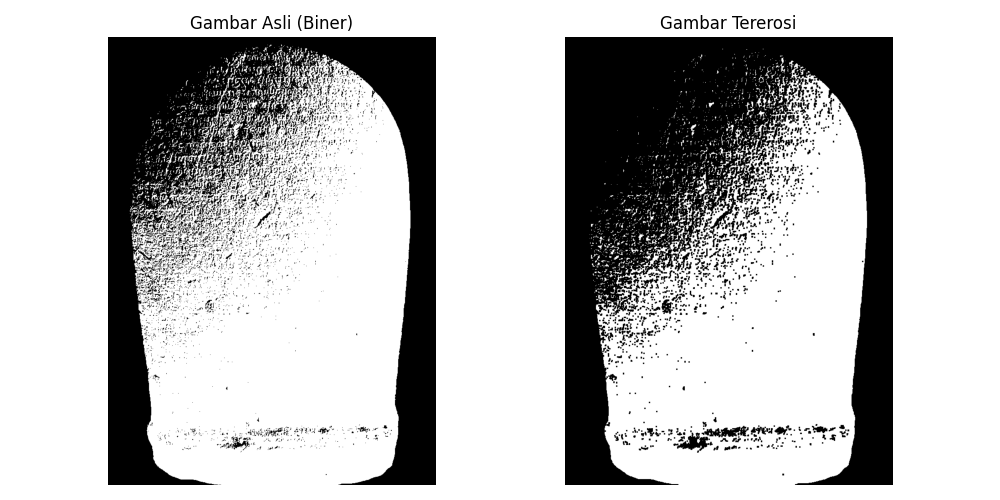

In [15]:
import numpy as np
from skimage.morphology import erosion, footprint_rectangle
from skimage.io import imread
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import IPython.display as display
import io
import base64

# Memuat gambar dari file
image_path = '/content/aksara_jawa (1).png'
original_color_image = imread(image_path)

# Mengonversi gambar ke skala abu-abu jika bukan grayscale
# Periksa juga apakah ada saluran alfa (4 saluran) dan buang jika ada
if original_color_image.ndim == 3:
    if original_color_image.shape[-1] == 4: # Jika ada 4 saluran (RGBA)
        original_color_image = original_color_image[..., :3] # Ambil hanya RGB
    original_gray_image = rgb2gray(original_color_image)
else:
    original_gray_image = original_color_image

# Mengonversi gambar grayscale ke biner (misalnya, dengan thresholding sederhana)
# Anda mungkin perlu menyesuaikan nilai threshold tergantung pada gambar
threshold = 0.5 # Nilai ambang batas, sesuaikan jika perlu
original_image = original_gray_image < threshold # Membuat area gelap menjadi True (1)

# Menentukan elemen struktural (kernel) untuk erosi
# Menggunakan footprint_rectangle sebagai pengganti square yang sudah deprecated
selem = footprint_rectangle((3, 3)) # Contoh: elemen struktural persegi 3x3

# Melakukan operasi erosi
eroded_image = erosion(original_image, selem)

# Memvisualisasikan gambar asli dan gambar yang tererosi
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Gambar Asli (Biner)')
axes[0].axis('off')

axes[1].imshow(eroded_image, cmap='gray')
axes[1].set_title('Gambar Tererosi')
axes[1].axis('off')

plt.tight_layout()

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Morphological Erosion of Aksara Jawa Image"
display.display(display.Markdown(F"![{alt}]({image})"))
plt.close(fig)
